In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Fish.csv")

In [4]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [5]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


<Axes: xlabel='Length1', ylabel='Weight'>

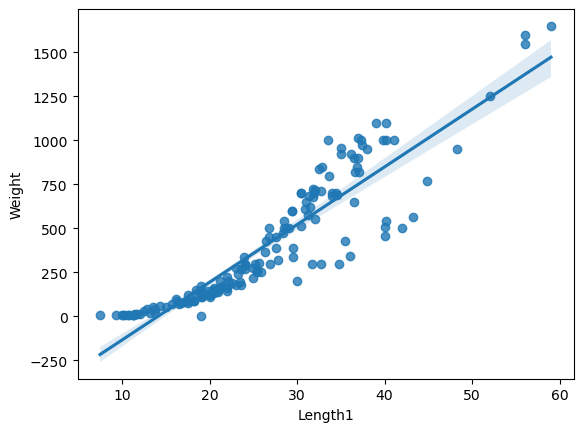

In [11]:
sns.regplot(data=df,x='Length1',y="Weight")

In [13]:
#For Predicting weight from length1
x=df[['Length1']]
y=df[["Weight"]]

In [15]:
#Split into 2 part train and test
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


In [22]:
#Build a model
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [25]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
model.coef_

array([[32.44308998]])

In [29]:
model.intercept_

array([-464.13411601])

In [33]:
y_pred=model.predict(x_test)

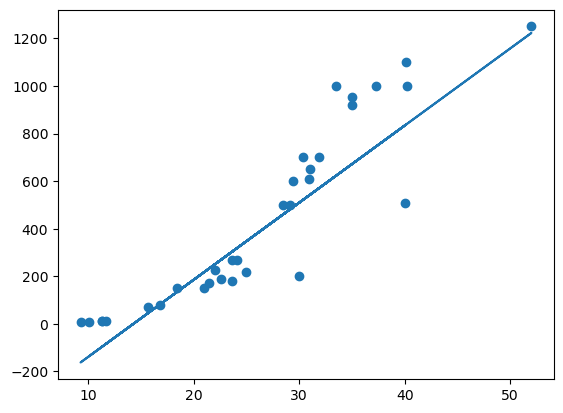

In [34]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [37]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821387
0.8116084146869396


In [43]:
model.predict([[25]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[346.94313356]])

In [44]:
#Ex 2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pandas as pd
import numpy as np

In [45]:
df=pd.read_csv("Fish.csv")
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [49]:
x=df.drop(['Species',"Weight"],axis=1)
y=df[["Weight"]]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

109.0632714203943
21303.013279012113
0.8679594534557271


In [53]:
#Ex 3
df=pd.read_csv("Fish.csv")
x=df.drop(['Species',"Weight"],axis=1)
y=df[["Weight"]]
test=[0.75,0.80,0.85,0.90,0.95]
mse=[]
r2=[]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
print(mse)
print(r2)

[21485.14792353189, 19141.389851256346, 24762.671477245258, 20643.648028028125, 48861.047183691735]
[0.8482152077173417, 0.8607660310160297, 0.8173371854115964, 0.8468087122619059, 0.6289837470636086]


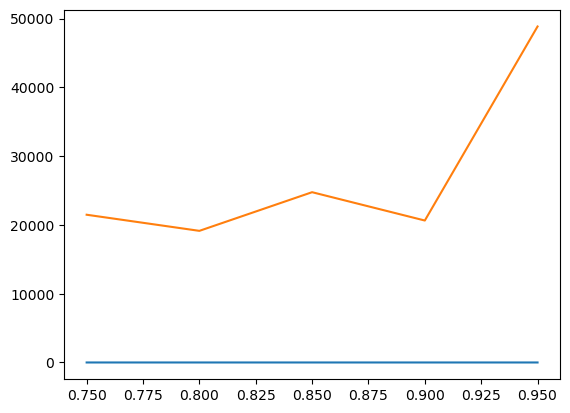

In [56]:
plt.plot(test,r2)
plt.plot(test,mse)

In [60]:
df=pd.read_csv("Ice_cream selling data.csv")

In [63]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [64]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

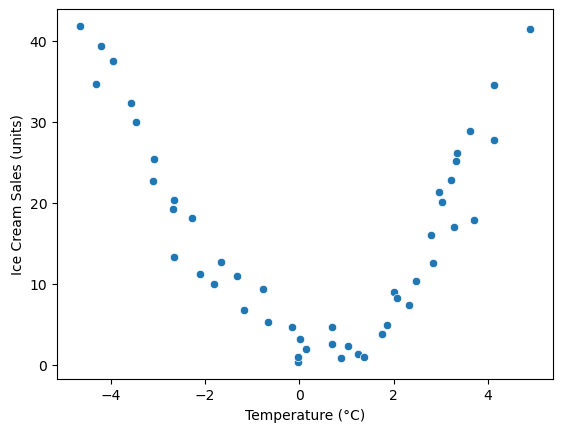

In [65]:
sns.scatterplot(data=df,x="Temperature (°C)",y="Ice Cream Sales (units)")

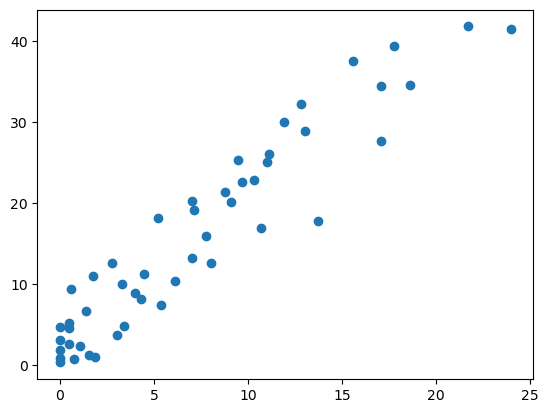

In [66]:
plt.scatter(df["Temperature (°C)"]*df["Temperature (°C)"],df["Ice Cream Sales (units)"])

In [67]:
x=df[["Temperature (°C)"]]*df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

4.527220044672891
27.28721522115138
0.8665029086853921


In [46]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

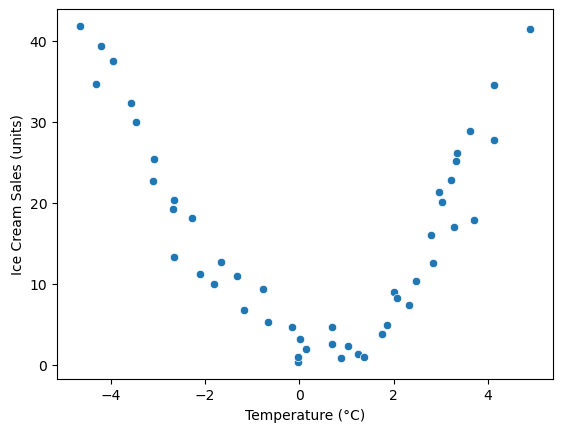

In [48]:
df=pd.read_csv("Ice_cream selling data.csv")
sns.scatterplot(data=df,x="Temperature (°C)",y="Ice Cream Sales (units)")

In [49]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Convert polynomial data

In [51]:
poly=PolynomialFeatures(degree=2)

In [52]:
x_train_poly=poly.fit_transform(x_train)

In [53]:
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [54]:
x_test_poly=poly.transform(x_test)

In [55]:
x_test_poly

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [56]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
model.coef_

array([[ 0.        , -0.70641926,  1.87145125]])

In [58]:
model.intercept_

array([2.76830583])

In [37]:
y_pred=model.predict(x_test_poly)
print(r2_score(y_pred,y_test))

0.8666323293264795


In [62]:
model.predict(poly.transform([[15]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[413.24854806]])

In [68]:
df=pd.read_csv("Fish.csv")

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
y=df[["Weight"]]
x=df.drop(['Species',"Weight"],axis=1)

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
r2=[]
r2_max=0
for i in range (2,8):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2.append(r2_score(y_pred,y_test))
    if r2_max<r2_score(y_pred,y_test):
        r2_max=r2_score(y_pred,y_test)
        y_ans=model.predict(poly.transform([[12,13,15,5,5]]))
print(y_ans)

[[349.73726572]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
